In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV




In [2]:
df=pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [26]:
df.head()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,True,False,False,False,True,False,False,True,False
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,False,False,False,False,False,True,False,False,True
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,False,False,True,False,False,True,False,True,False
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,False,False,True,True,False,False,False,False,True
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,False,True,False,False,False,False,True,False,False


In [25]:
df.tail()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
2635,2021,10,13488,14333,113771.10,120,719,1454.68,4273,False,True,False,False,False,False,True,False,True
2636,2019,7,18300,18407,81889.67,82,487,1336.81,9833,False,True,False,False,True,False,False,False,True
2637,2019,9,13291,14839,97139.38,100,580,1156.32,13709,False,False,False,False,True,False,False,False,False
2638,2020,5,3471,3714,69990.57,60,358,186.39,6754,False,False,False,False,False,False,False,True,False
2639,2018,8,2639,2929,51676.24,82,474,187.63,14297,False,False,True,False,True,False,False,False,False


In [5]:
df.shape

(2640, 12)

In [6]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [8]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [9]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [12]:
df=pd.get_dummies(df,columns=['Region','Model','Source_Type'],drop_first=True)

In [13]:
df.head()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,True,False,False,False,True,False,False,True,False
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,False,False,False,False,False,True,False,False,True
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,False,False,True,False,False,True,False,True,False
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,False,False,True,True,False,False,False,False,True
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,False,True,False,False,False,False,True,False,False


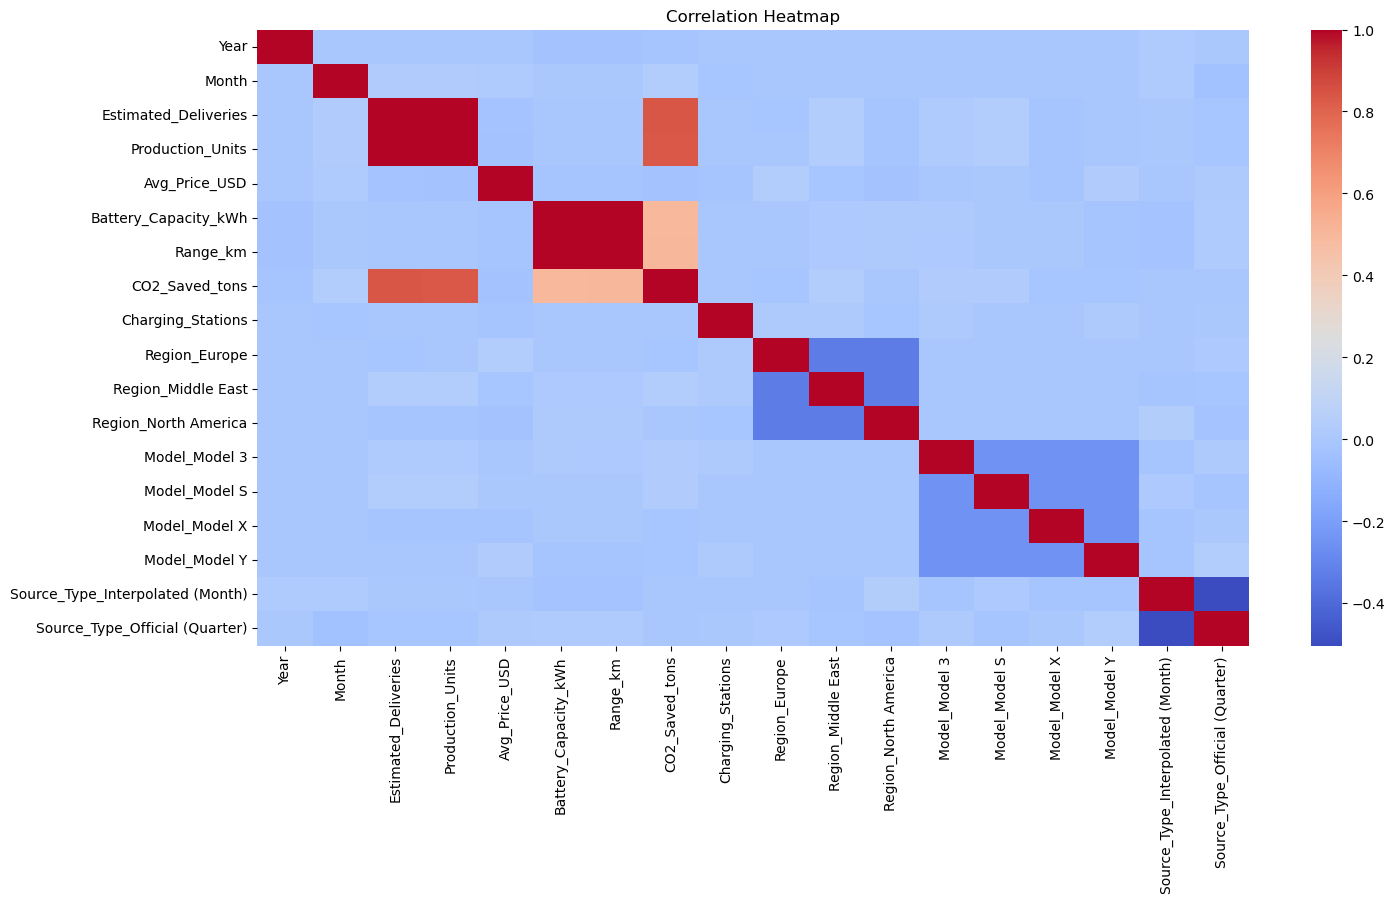

In [14]:
##Correlation Heatmap
plt.figure(figsize=(16,8))
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

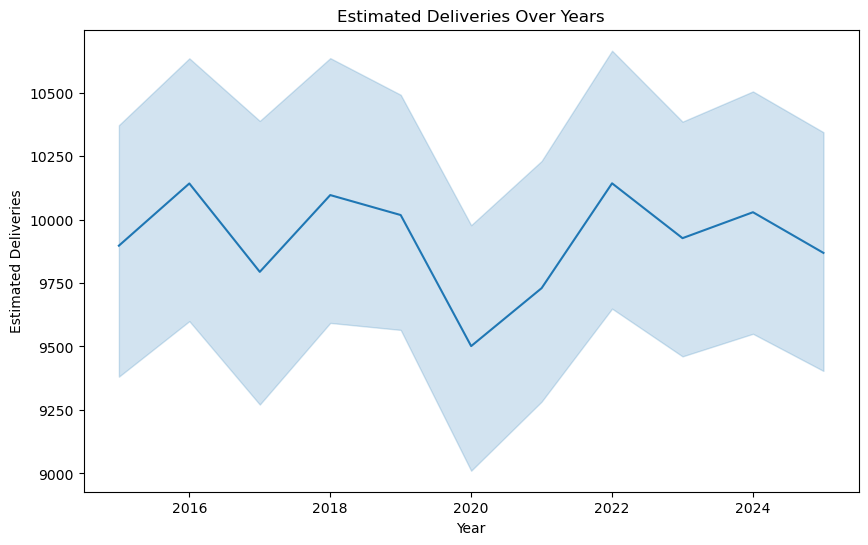

In [15]:
##Deliveries trend over Years
plt.figure(figsize=(10,6))
sns.lineplot(x='Year',y='Estimated_Deliveries',data=df)
plt.title("Estimated Deliveries Over Years")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.show()


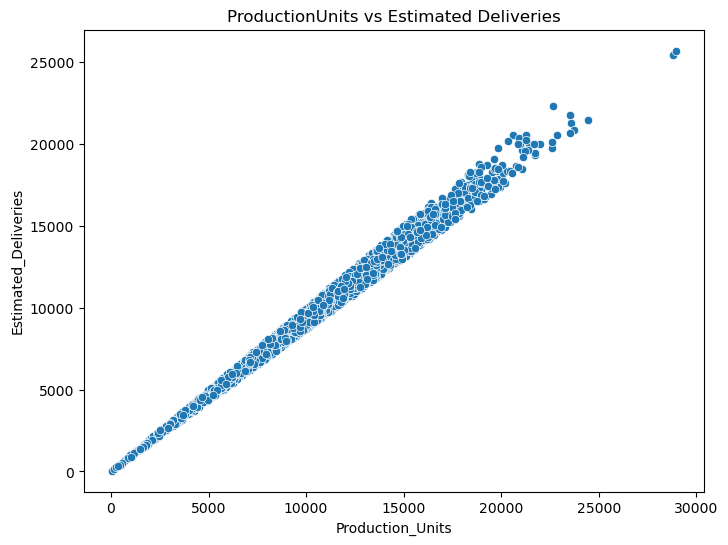

In [16]:
#Production vs Deliveries
plt.figure(figsize=(8,6))
sns.scatterplot(x='Production_Units',y='Estimated_Deliveries',data=df)
plt.title("ProductionUnits vs Estimated Deliveries")
plt.show()

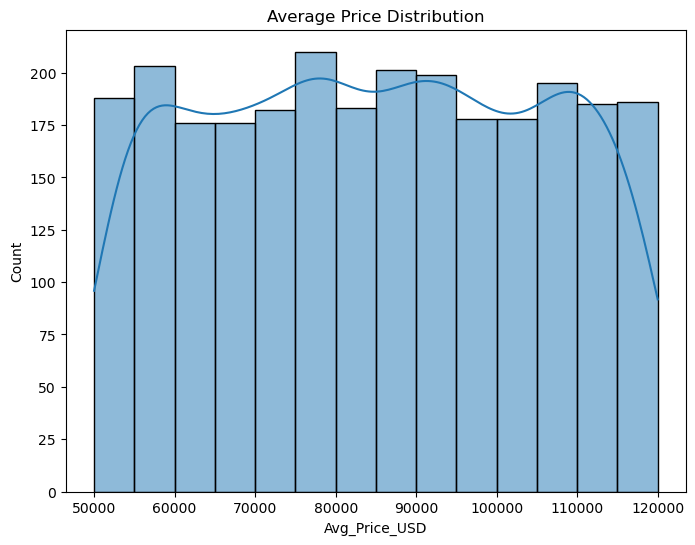

In [17]:
#Average Price Distribution
plt.figure(figsize=(8,6))
sns.histplot(df['Avg_Price_USD'],kde=True)
plt.title("Average Price Distribution")
plt.show()

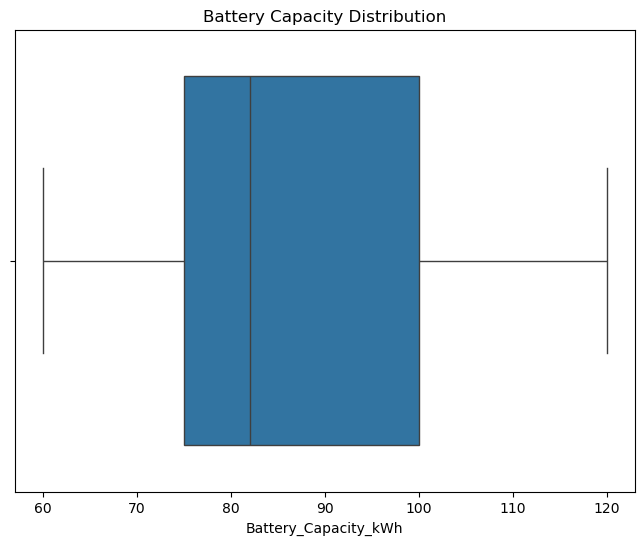

In [18]:
#Battery Capacity Distribution
plt.figure(figsize=(8,6))
sns.boxplot(x=df['Battery_Capacity_kWh'])
plt.title("Battery Capacity Distribution")
plt.show()

In [19]:
#Feature Selection
X=df.drop('Estimated_Deliveries',axis=1)
y=df['Estimated_Deliveries']


In [20]:
#Train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
#1st Linear Regression -as base model
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)

#Evaluation
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 309.7036740991359
RMSE: 384.0291152725069
R2 Score: 0.9901062987611021


In [22]:
#2nd Random Forest Model- as second model for checing more accuracy
rf=RandomForestRegressor()
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)

#Evaluation
mae = mean_absolute_error(y_test, y_pred_rf)

mse = mean_squared_error(y_test, y_pred_rf)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_rf)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 319.7311931818182
RMSE: 404.29910791585115
R2 Score: 0.9890343077234198


In [28]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 16.2 MB/s eta 0:00:07
   - -------------------------------------- 4.7/101.7 MB 13.2 MB/s eta 0:00:08
   -- ------------------------------------- 5.8/101.7 MB 9.9 MB/s eta 0:00:10
   -- ------------------------------------- 6.3/101.7 MB 8.5 MB/s eta 0:00:12
   -- ------------------------------------- 6.8/101.7 MB 6.9 MB/s eta 0:00:14
   -- ------------------------------------- 7.3/101.7 MB 6.1 MB/s eta 0:00:16
   --- ------------------------------------ 8.1/101.7 MB 5.5 MB/s eta 0:00:17
   --- ------------------------------------ 8.7/101.7 MB 5.3 MB/s eta 0:00:18
   --- ------------------------------------ 9.4/101.7 MB 5.1 MB/s eta 0:00:19
   ---- ----------------------------------- 10.5/101.7 MB 5.0 MB/s eta 0:00:19
   ---- ----------------------------------- 11.5/101.7 MB 5.0 MB/s eta 0:00:19
   ----- ---------------------------------- 12.8/101.7 MB 5.0 MB/s 

In [30]:
#XgBoost-Comaprision with above models
xgb=XGBRegressor()
xgb.fit(X_train,y_train)
y_pred_xgb=xgb.predict(X_test)

#Evaluation
mae = mean_absolute_error(y_test, y_pred_xgb)

mse = mean_squared_error(y_test, y_pred_xgb)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_xgb)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 230.99159240722656
RMSE: 307.14247508281886
R2 Score: 0.9936713576316833


In [31]:
#Hyperparamter Tuning
params={
   'n_estimators':[100,200],
   'max_depth':[3,5]
}

In [32]:
grid=GridSearchCV(
XGBRegressor(),
    params,cv=3
)

In [33]:
grid.fit(X_train,y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [35]:
print(grid.best_params_)

{'max_depth': 3, 'n_estimators': 200}


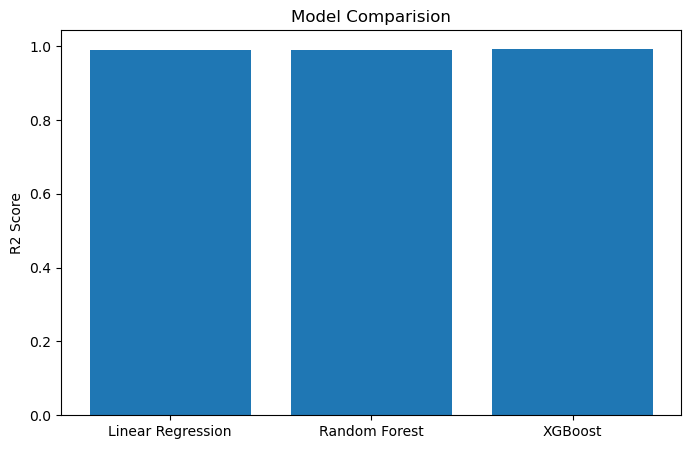

In [37]:
#Comparision
models = ['Linear Regression', 'Random Forest', 'XGBoost']

scores = [
    r2_score(y_test, y_pred),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_xgb)
]

#Graph 
plt.figure(figsize=(8,5))
plt.bar(models,scores)
plt.title("Model Comparision")
plt.ylabel("R2 Score")
plt.show()

In [39]:
#Forecasting ARIMA Model
from statsmodels.tsa.arima.model import ARIMA


In [40]:
df['Date']=pd.to_datetime(df['Year'].astype(str)+'-'+df['Month'].astype(str))

In [41]:
ts=df[['Date','Estimated_Deliveries']]

In [42]:
ts.set_index('Date',inplace=True)

In [43]:
ts=ts.sort_index()

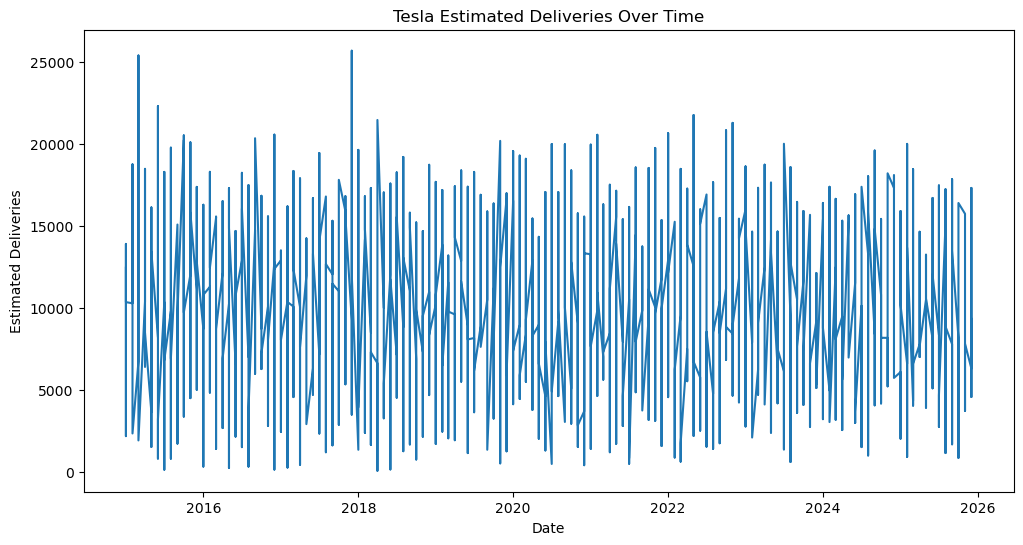

In [44]:
plt.figure(figsize=(12,6))
plt.plot(ts.index,ts['Estimated_Deliveries'])
plt.title("Tesla Estimated Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

In [45]:
model=ARIMA(ts['Estimated_Deliveries'],
            order=(1,1,1)
           )

C:\Users\BIT\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\BIT\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\BIT\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [46]:
result=model.fit()

In [47]:
forecast=result.forecast(steps=12)

C:\Users\BIT\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [48]:
forecast

2640    9931.045748
2641    9918.492381
2642    9918.749857
2643    9918.744576
2644    9918.744684
2645    9918.744682
2646    9918.744682
2647    9918.744682
2648    9918.744682
2649    9918.744682
2650    9918.744682
2651    9918.744682
Name: predicted_mean, dtype: float64

In [50]:
future_dates=pd.date_range(start=ts.index[-1],periods=12,freq='M')


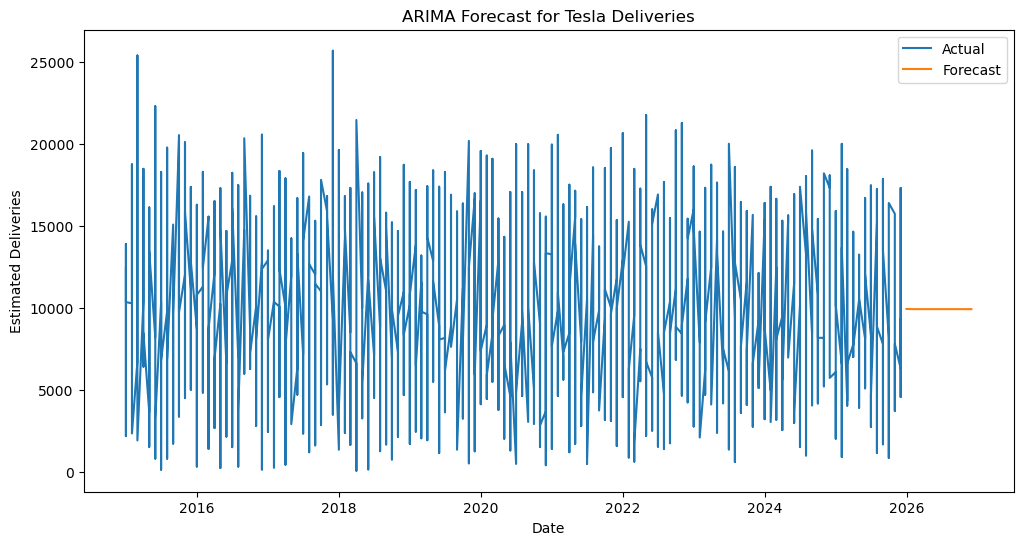

In [51]:
plt.figure(figsize=(12,6))
plt.plot(ts.index,ts['Estimated_Deliveries'],label='Actual')
plt.plot(future_dates,forecast,label='Forecast')
plt.title("ARIMA Forecast for Tesla Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.show()

In [52]:
print(result.summary())

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                 2640
Model:                   ARIMA(1, 1, 1)   Log Likelihood              -25593.592
Date:                  Fri, 29 May 2026   AIC                          51193.184
Time:                          12:36:09   BIC                          51210.818
Sample:                               0   HQIC                         51199.568
                                 - 2640                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0205      0.019     -1.071      0.284      -0.058       0.017
ma.L1         -1.0000      0.028    -36.078      0.000      -1.054      -0.946
sigma2      1.549e+07   1.79e-09   8

In [53]:
#Model Saving
import joblib
joblib.dump(xgb,'tesla_model.pkl')
print("Model saved Successfully")

Model saved Successfully


In [54]:
loaded_model=joblib.load('tesla_model.pkl')
print(loaded_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)


# Final Conclusion

1. Successfully designed and implemented an end-to-end Machine Learning pipeline using Tesla deliveries and production data.

2. Performed data preprocessing, duplicate handling, categorical encoding, and feature engineering to prepare the dataset for modeling.

3. Conducted Exploratory Data Analysis (EDA) using various visualizations to identify trends, correlations, and insights related to Tesla sales, production, pricing, and EV growth.

4. Built and evaluated multiple regression models including Linear Regression, Random Forest Regressor, and XGBoost Regressor for predictive analysis.

5. Applied hyperparameter tuning using GridSearchCV to optimize model performance and improve prediction accuracy.

6. Compared model performances using evaluation metrics such as MAE, RMSE, and R² Score.

7. Implemented ARIMA Time Series Forecasting to predict future Tesla delivery trends based on historical patterns.

8. Saved the best-performing model using Joblib for future prediction and deployment purposes.

9. The project demonstrates the effectiveness of Machine Learning and Time Series Forecasting techniques in analyzing sales trends, production patterns, and future EV market growth.